# Section 27 - Complete Linear Regression 

## 27.11 - Linear Regression Practicals.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [5]:
df = pd.read_csv("height-weight.csv")
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

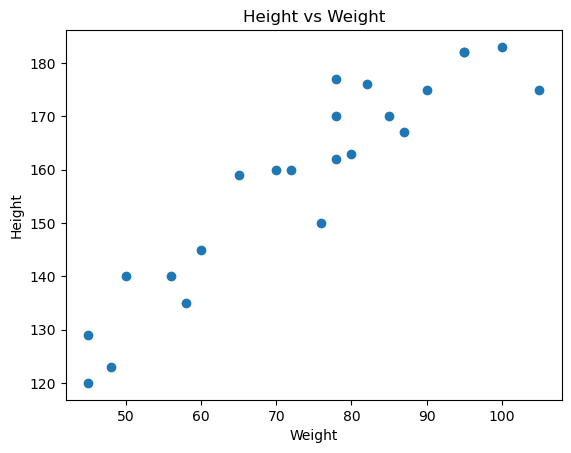

In [6]:
# Scatter Plot
plt.scatter(df['Weight'], df['Height'])
plt.title("Height vs Weight")
plt.xlabel("Weight")
plt.ylabel("Height")

In [7]:
# Correlation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


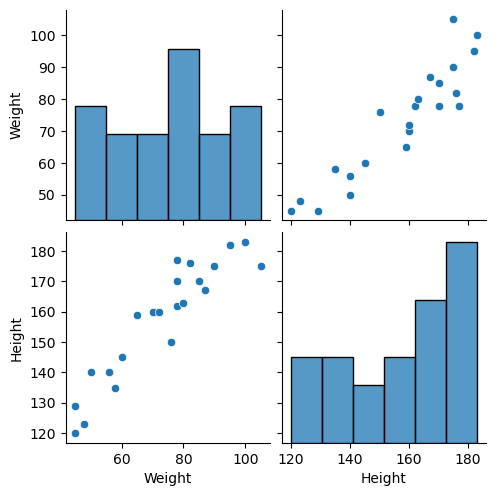

In [8]:
sns.pairplot(df)

Note: This is just simple Linear Regression, usually when we do Multiple Linear Regression, we also check the relationship between the independent feature. We will learn to check multicollinearity, (its a scenario where in we have 2 to 3 independent features and if the correlation between those independent feature are high then we can neglect those features which are highly correlated.)

In [9]:
# Independent and Dependent Features
x = df[["Weight"]]
y = df["Height"]

### Important Note:
- Suppose I want all of my weight feature in the x-axis....
So if i write like this " x = df["Weight"] ",so the x that is basically getting created is a series not as dataframe. Series means just one single record.
- You have to take care of very important thing, whenever you probably create independent feature, we use one additional bracket, we will get a dataframe.

## "Always make Sure that your independent feature, should be in the form of dataframe or 2-D Array"

- So using this -> " x = df["Weight"] ", we will get 1-D Array.(not good for our model).
- That's why we use x = df[["Weight"]]
- Dependent Feature can be in Series / 1-D Array. 

In [10]:
# Train Test Split
from sklearn.model_selection import train_test_split 

In [47]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [48]:
x_train.shape

(17, 1)

### Standardization
- Why it is basically required???
- Lets say we have 2 features, Weight(calculated in kg) and Height(calculated in cm), so whatever values we get in this are of different units. 
- And you know in sklearn we use gradient descent. So if my value is higher the  it will take more time to reach to global minima. Bcoz all the maths will be apply to a bigger value which is not suitable. 
- So the solution is, we take up each independent feature and we apply a simple formula which is called as z score. 
- And this formula will basically be converting all the vslues with mean=0 and sd=1.

In [49]:
# Standardization
from sklearn.preprocessing import StandardScaler

In [50]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)

### This transformation will be applied to all my extreme values...and the datapoints we get, will have mean as 0 and standard deviation as 1.


### The same thing I need to do with the test data.
- But always remember in the test data we do not apply Fit Transform.

### The difference between fit_transform and transform 
- Initially whatever data I have in train(the traning data) I'm going to use the Main Mean and satndard Deviation(i.e. The mean and sd calculated for the training data set.)
- The same mean and sd will be used for the testing data.

- So when we use fit_transform(), it calculates the mean and sd for the dataset and uses it in the z-score formula. 
- And when we use transform(), it uses the same mean and sd that was calculated by fit_transform().

### If I use fit_transform() again, then again the mean and standard deviation will be calculated for the test data.

## And we do this bcoz of the Data Leakage.
i.e. I dont want my trainig data to know anything about my test data.

In [51]:
x_test = scaler.transform(x_test)

In [52]:
# Now we will apply the Simple Linear Regression 
from sklearn.linear_model import LinearRegression


## Parameters of Linear Regression
- fit_intercept: Whether to calculate the intercept for this model or not.
- normalize: If set true, the regressor X will be normalized before regression. (We have already done that...we have normalized and standardize using standard scaler).
- copy_x: If true, X will be copied, else it may be overwritten.
- n_jobs: Its a very important parameter. If you set this as minus one it is going to use all the processors that are in your system to converge and train the model.
- positive: When set to true, forces the corfficents to be positive.

In [53]:
# Parameters:
# LinearRegression(fit_intercept=True, normalize=False, copy_X=True, n_jobs=None)
regression  = LinearRegression(n_jobs=-1)

In [54]:
regression.fit(x_train, y_train)

LinearRegression(n_jobs=-1)

In [55]:
print("Coefficient or slope: ",regression.coef_) # its the corfficient: beta1
print("Intercept: ",regression.intercept_)

Coefficient or slope:  [17.2982057]
Intercept:  156.47058823529412


This corfficeint says, that 1 unit value change in weight is 17.29 unit change in the height. 

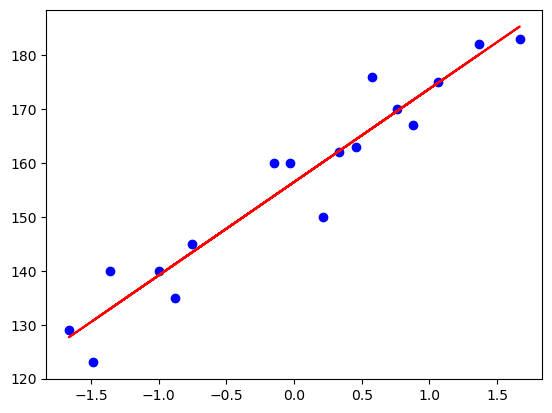

In [56]:
# Ploting of Best Fit Line wrt the training data
plt.scatter(x_train, y_train, color='blue')
plt.plot(x_train, regression.predict(x_train), color = 'r')

In [57]:
# Prediction for test data.
y_pred = regression.predict(x_test)

In order to see how the result is, we will try to check with the performance metrics.

In [58]:
# Performance Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [59]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error: ", mse)
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error: ", mae)
rmse = np.sqrt(mse)
print("Root Mean Squared Error: ", rmse)

Mean Squared Error:  114.84069295228699
Mean Absolute Error:  9.665125886795005
Root Mean Squared Error:  10.716374991212605


In [60]:
# R Square
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print("R Square: ", r2)

R Square:  0.7360826717981276


In [61]:
adjusted_r2 = 1 - (1-r2)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)
print("Adjusted R Square: ", adjusted_r2)

Adjusted R Square:  0.6701033397476595


In [62]:
# OLS Linear Regression
import statsmodels.api as sm

In [63]:
model = sm.OLS(y_train, x_train).fit()

In [64]:
prediction = model.predict(x_test)
print(prediction)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [65]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Fri, 09 May 2025   Prob (F-statistic):                       0.664
Time:                        23:55:30   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

c:\Users\OM MAKWANA\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=17
  res = hypotest_fun_out(*samples, **kwds)


In [66]:
# prediction for new data
regression.predict(scaler.transform([[72]])) # 150 is the weight

c:\Users\OM MAKWANA\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])